In [184]:
import pandas as pd

df = pd.read_csv('./employee_data.csv')
print(df.head())

df = df.drop(columns=['EmployeeNumber'])

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   34        No  Travel_Frequently        702  Research & Development   
1   38        No      Travel_Rarely        833  Research & Development   
2   51        No      Travel_Rarely        833  Research & Development   
3   60        No      Travel_Rarely       1179                   Sales   
4   23        No      Travel_Rarely        571  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                16          4  Life Sciences              1             838   
1                18          3        Medical              1            1766   
2                 1          3  Life Sciences              1             353   
3                16          4      Marketing              1             732   
4                12          2          Other              1            1982   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [185]:
print(df.head()['StandardHours'].nunique())
print(df.head()['Over18'].nunique())
print(df.head()['EmployeeCount'].nunique())

df = df.drop(columns=['StandardHours', 'Over18', 'EmployeeCount'])

1
1
1


In [186]:
df.isna().sum().sort_values(ascending=False)

Age                         0
MonthlyIncome               0
YearsSinceLastPromotion     0
YearsInCurrentRole          0
YearsAtCompany              0
WorkLifeBalance             0
TrainingTimesLastYear       0
TotalWorkingYears           0
StockOptionLevel            0
RelationshipSatisfaction    0
PerformanceRating           0
PercentSalaryHike           0
OverTime                    0
NumCompaniesWorked          0
MonthlyRate                 0
MaritalStatus               0
Attrition                   0
JobSatisfaction             0
JobRole                     0
JobLevel                    0
JobInvolvement              0
HourlyRate                  0
Gender                      0
EnvironmentSatisfaction     0
EducationField              0
Education                   0
DistanceFromHome            0
Department                  0
DailyRate                   0
BusinessTravel              0
YearsWithCurrManager        0
dtype: int64

In [187]:
from sklearn.preprocessing import OneHotEncoder

columns_to_encode = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'Attrition', 'JobRole', 'MaritalStatus', 'OverTime']
ohe = OneHotEncoder(sparse_output=False)
encoded_data = ohe.fit_transform(df[columns_to_encode])
encoded_df = pd.DataFrame(encoded_data, columns=ohe.get_feature_names_out(columns_to_encode))
df = pd.concat([df.drop(columns=columns_to_encode), encoded_df], axis=1)
print(df.columns)

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'BusinessTravel_Non-Travel', 'BusinessTravel_Travel_Frequently',
       'BusinessTravel_Travel_Rarely', 'Department_Human Resources',
       'Department_Research & Development', 'Department_Sales',
       'EducationField_Human Resources', 'EducationField_Life Sciences',
       'EducationField_Marketing', 'EducationField_Medical',
       'EducationField_Other', 'EducationField_Technical Degree',
       'Gender_Female', 'Gender_Male', 'Attrition_No', 'Attrition_Yes',
       'JobRole_Healthcare Repr

In [188]:
df.corrwith(df['MonthlyIncome']).sort_values(ascending=False)

MonthlyIncome                        1.000000
JobLevel                             0.947914
TotalWorkingYears                    0.771027
JobRole_Manager                      0.618505
YearsAtCompany                       0.513625
Age                                  0.506209
JobRole_Research Director            0.473482
YearsInCurrentRole                   0.356812
YearsSinceLastPromotion              0.340469
YearsWithCurrManager                 0.339835
Attrition_No                         0.156702
NumCompaniesWorked                   0.140602
Education                            0.088127
JobRole_Healthcare Representative    0.077132
Department_Sales                     0.071252
EducationField_Marketing             0.062355
JobRole_Manufacturing Director       0.055605
JobRole_Sales Executive              0.054119
MaritalStatus_Married                0.052193
MonthlyRate                          0.039362
Gender_Female                        0.036490
OverTime_Yes                      

In [189]:
df['age_x_experience'] = df['Age'] * df['YearsAtCompany']
df['age_group'] = df['Age'] // 10

df.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,OverTime_No,OverTime_Yes,age_x_experience,age_group
0,34,702,16,4,3,100,2,1,4,2553,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,170,3
1,38,833,18,3,2,60,1,2,4,5811,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,38,3
2,51,833,1,3,3,96,3,1,4,2723,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,51,5
3,60,1179,16,4,1,84,3,2,1,5405,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,120,6
4,23,571,12,2,4,78,3,1,4,2647,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,115,2


In [190]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
columns_to_scale = df.columns.drop('MonthlyIncome')
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

df.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,OverTime_No,OverTime_Yes,age_x_experience,age_group
0,-0.330281,-0.251453,0.829303,1.071617,0.255874,1.688102,-1.04365,-0.971272,1.158187,2553,...,2.055709,-0.540022,-0.241815,-0.533835,-0.920670,1.459564,0.627673,-0.627673,-0.367123,-0.26085
1,0.105557,0.073702,1.075922,0.092502,-0.659848,-0.275520,-2.46206,-0.056401,1.158187,5811,...,-0.486450,-0.540022,-0.241815,-0.533835,1.086166,-0.685136,-1.593187,1.593187,-0.811836,-0.26085
2,1.522032,0.073702,-1.020339,0.092502,0.255874,1.491740,0.37476,-0.971272,1.158187,2723,...,2.055709,-0.540022,-0.241815,-0.533835,1.086166,-0.685136,0.627673,-0.627673,-0.768039,1.80773
3,2.502669,0.932507,0.829303,1.071617,-1.575570,0.902653,0.37476,-0.056401,-1.542328,5405,...,-0.486450,1.851777,-0.241815,-0.533835,-0.920670,1.459564,0.627673,-0.627673,-0.535575,2.84202
4,-1.528837,-0.576607,0.336065,-0.886613,1.171596,0.608110,0.37476,-0.971272,1.158187,2647,...,-0.486450,-0.540022,-0.241815,-0.533835,-0.920670,1.459564,0.627673,-0.627673,-0.552420,-1.29514


In [191]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV

X = df.drop(columns=['MonthlyIncome'])
y = df['MonthlyIncome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def train_linear():
    linear_model = LinearRegression()
    linear_model.fit(X_train, y_train)
    return linear_model

def train_xgboost():
    xgb_model = XGBRegressor(random_state=42, max_depth=5)
    xgb_model.fit(X_train, y_train)
    return xgb_model

def train_xgboost_hyperparamterized():
    xgb = XGBRegressor(random_state=42)

    param_dist = {
        "n_estimators": [100, 300, 500, 800],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "max_depth": [3, 5, 7, 10],
        "subsample": [0.6, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.8, 1.0]
    }

    random_search = RandomizedSearchCV(
        xgb,
        param_distributions=param_dist,
        n_iter=20,
        scoring="neg_root_mean_squared_error",
        cv=3,
        verbose=1,
        n_jobs=-1
    )
    random_search.fit(X_train, y_train)
    return random_search.best_estimator_

linear_model = train_linear()
xgb_model = train_xgboost()
xgb_hyper_model = train_xgboost_hyperparamterized()

Fitting 3 folds for each of 20 candidates, totalling 60 fits


In [192]:
def test_linear():
    y_pred = linear_model.predict(X_test)
    linear_rmse = root_mean_squared_error(y_test, y_pred)
    linear_r2 = r2_score(y_test, y_pred)

    print(f'Linear RMSE: {linear_rmse}')
    print(f'Linear R²: {linear_r2}')

    plt.scatter(y_test, y_pred)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.plot([min_val, max_val], [min_val, max_val])
    plt.show()

def test_xgboost():
    y_pred = xgb_model.predict(X_test)
    xgb_rmse = root_mean_squared_error(y_test, y_pred)
    xgb_r2 = r2_score(y_test, y_pred)

    print(f'XGBoost RMSE: {xgb_rmse}')
    print(f'XGBoost R²: {xgb_r2}')

    plt.scatter(y_test, y_pred)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.plot([min_val, max_val], [min_val, max_val])
    plt.show()

def test_xgboost_hyperparamterized():
    y_pred = xgb_hyper_model.predict(X_test)
    best_rmse = root_mean_squared_error(y_test, y_pred)
    best_r2 = r2_score(y_test, y_pred)
    print(f'Best XGBoost RMSE: {best_rmse}')
    print(f'Best XGBoost R²: {best_r2}')

    plt.scatter(y_test, y_pred)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.plot([min_val, max_val], [min_val, max_val])
    plt.show()

Linear RMSE: 1088.2100350375317
Linear R²: 0.9441808768811403


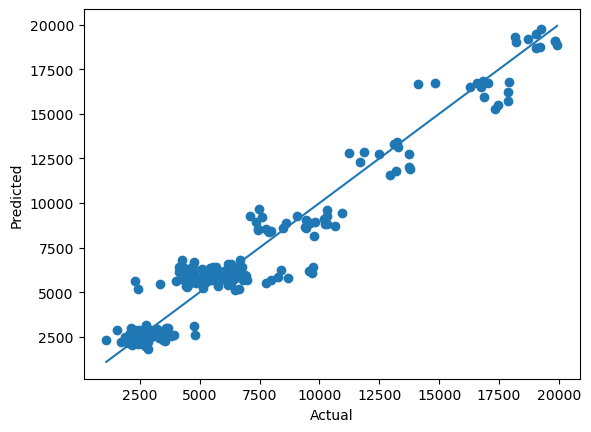

XGBoost RMSE: 1130.7694091796875
XGBoost R²: 0.9397293925285339


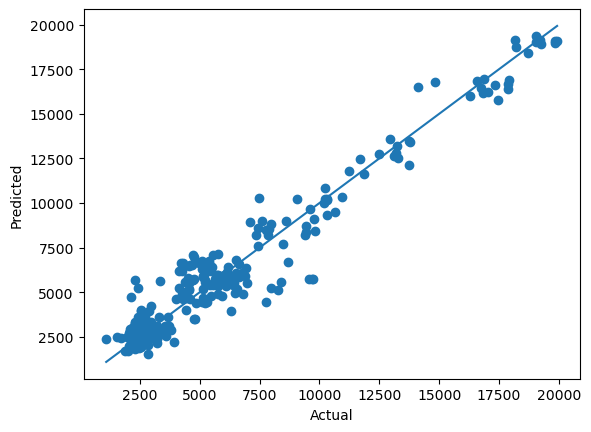

Best XGBoost RMSE: 1042.655029296875
Best XGBoost R²: 0.9487565159797668


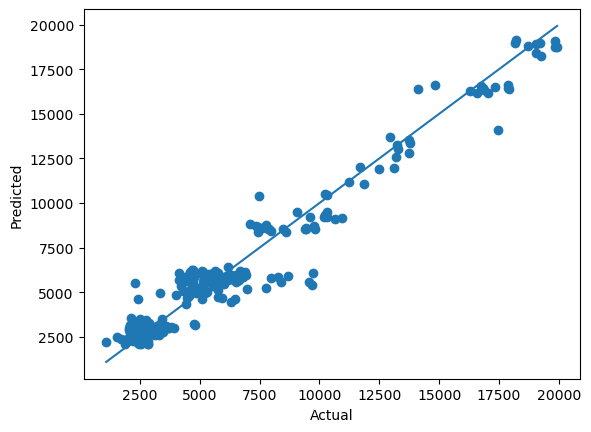

In [193]:
test_linear()
test_xgboost()
test_xgboost_hyperparamterized()

In [194]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
import numpy as np

df = pd.read_csv('./employee_data.csv')

def feature_engineering(X):
    X = X.copy()
    X['age_x_experience'] = X['Age'] * X['YearsAtCompany']
    X['age_group'] = X['Age'] // 10
    return X

drop_columns = ['EmployeeNumber', 'StandardHours', 'Over18', 'EmployeeCount']
feature_creator = FunctionTransformer(feature_engineering)

preprocessor = ColumnTransformer(
    transformers=[
        ('drop', 'drop', drop_columns),
        ('cat', OneHotEncoder(sparse_output=False), columns_to_encode),
        ('num', StandardScaler(), make_column_selector(dtype_include=np.number)),
    ]
)

pipeline = Pipeline(steps=[
    ('feature_engineering', feature_creator),
    ('preprocessor', preprocessor),
    ('model', train_xgboost_hyperparamterized())
])

X = df.drop(columns=['MonthlyIncome'])
y = df['MonthlyIncome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
final_rmse = root_mean_squared_error(y_test, y_pred)
final_r2 = r2_score(y_test, y_pred)
print(f'Final Pipeline RMSE: {final_rmse}')
print(f'Final Pipeline R²: {final_r2}')

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Final Pipeline RMSE: 1049.5205078125
Final Pipeline R²: 0.9480794668197632


In [195]:
import pickle

with open('Group6_pipeline_regression.pkl', 'wb') as f:
    pickle.dump(pipeline, f)